<a href="https://colab.research.google.com/github/peterdomjan-maker/Biomed2026/blob/main/S6_PYTORCH_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIOMED-DATA 26 · Session 6
## A tabular transformer you can train (PyTorch)
**A compact feature-tokenizer + Transformer encoder for the diagnosis — small enough to train on CPU in Colab**

> **STUDENT — fill in the blanks**
>
> Dataset: UCI Heart Disease (`ucimlrepo`, id=45). Runs in Colab: `Runtime → Run all`.
> Semmelweis University · Luca Szegletes (BME)
---

This notebook builds a **real, trainable tabular transformer** from scratch in PyTorch — not a library black box.
The design is a small **FT-Transformer**: every feature (numeric or categorical) becomes a token, a `[CLS]` token is
prepended, a Transformer encoder lets the tokens attend to one another, and the `[CLS]` output drives the prediction.

It is deliberately tiny (embedding size 32, 2 layers, 4 heads) so it trains in seconds on a CPU. The honest goal is
fluency with the architecture — on 300 patients it will land near gradient boosting, not clearly beat it.

In [1]:
# PyTorch is preinstalled in Colab. Only the data/metrics helpers are needed.
!pip -q install ucimlrepo scikit-learn

## 0. Load and preprocess (numeric scaled, categorical to indices)

In [2]:
import numpy as np, pandas as pd, torch, torch.nn as nn
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import roc_auc_score
torch.manual_seed(0); np.random.seed(0)

heart = fetch_ucirepo(id=45)
X = heart.data.features.copy()
y = (heart.data.targets["num"] > 0).astype(int).values
num_cols = ["age","trestbps","chol","thalach","oldpeak"]
cat_cols = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# numeric: impute + scale
imp_n = SimpleImputer(strategy="median"); sc = StandardScaler()
Xn_tr = sc.fit_transform(imp_n.fit_transform(X_tr[num_cols])).astype("float32")
Xn_te = sc.transform(imp_n.transform(X_te[num_cols])).astype("float32")

# categorical: impute + ordinal-encode to integer indices (unknown -> its own index 0)
imp_c = SimpleImputer(strategy="most_frequent")
oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
Xc_tr = oe.fit_transform(imp_c.fit_transform(X_tr[cat_cols]))
Xc_te = oe.transform(imp_c.transform(X_te[cat_cols]))
Xc_tr = (Xc_tr + 1).astype("int64")                 # shift so unknown(-1) -> 0
Xc_te = np.clip(Xc_te + 1, 0, None).astype("int64")
cardinalities = [int(Xc_tr[:,i].max()) + 1 for i in range(len(cat_cols))]  # embedding sizes
print("numeric:", Xn_tr.shape, "categorical:", Xc_tr.shape, "cardinalities:", cardinalities)

numeric: (242, 5) categorical: (242, 8) cardinalities: [3, 5, 3, 4, 3, 4, 5, 4]


## 1. The model: feature tokenizer + Transformer encoder

In [3]:
class FeatureTokenizer(nn.Module):
    def __init__(self, n_num, cat_cardinalities, d):
        super().__init__()
        self.d = d

        # Numerical feature tokenizer
        self.num_w = nn.Parameter(torch.randn(n_num, d) * 0.02)
        self.num_b = nn.Parameter(torch.zeros(n_num, d))

        # Categorical feature tokenizer
        self.cat_emb = nn.ModuleList([
            nn.Embedding(c, d) for c in cat_cardinalities
        ])

        # CLS token
        self.cls = nn.Parameter(torch.randn(1, 1, d) * 0.02)

    def forward(self, x_num, x_cat):
        B = x_num.size(0)

        # Numerical tokens
        num_tok = x_num.unsqueeze(-1) * self.num_w + self.num_b

        # Categorical tokens
        cat_tok = torch.stack(
            [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_emb)],
            dim=1
        )

        # CLS token repeated for each row in batch
        cls = self.cls.expand(B, -1, -1)

        # Final token sequence
        return torch.cat([cls, num_tok, cat_tok], dim=1)


class TabTransformer(nn.Module):
    def __init__(self, n_num, cat_cardinalities, d=32, heads=4, layers=2, p=0.1):
        super().__init__()

        self.tok = FeatureTokenizer(n_num, cat_cardinalities, d)

        layer = nn.TransformerEncoderLayer(
            d_model=d,
            nhead=heads,
            dim_feedforward=2 * d,
            dropout=p,
            batch_first=True,
            activation="gelu"
        )

        self.encoder = nn.TransformerEncoder(
            layer,
            num_layers=layers
        )

        self.head = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(d, 1)
        )

    def forward(self, x_num, x_cat):
        tokens = self.tok(x_num, x_cat)
        z = self.encoder(tokens)

        # take the [CLS] token: index 0 along token dimension
        cls = z[:, 0]

        return self.head(cls).squeeze(-1)


model = TabTransformer(
    len(num_cols),
    cardinalities,
    d=32,
    heads=4,
    layers=2
)

print(model)

TabTransformer(
  (tok): FeatureTokenizer(
    (cat_emb): ModuleList(
      (0): Embedding(3, 32)
      (1): Embedding(5, 32)
      (2): Embedding(3, 32)
      (3): Embedding(4, 32)
      (4): Embedding(3, 32)
      (5): Embedding(4, 32)
      (6): Embedding(5, 32)
      (7): Embedding(4, 32)
    )
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )

## 2. Tensors

In [4]:
def to_tensors(Xn, Xc, y=None):
    t = (torch.tensor(Xn), torch.tensor(Xc))
    return t + ((torch.tensor(y, dtype=torch.float32),) if y is not None else ())
Xn_tr_t, Xc_tr_t, y_tr_t = to_tensors(Xn_tr, Xc_tr, y_tr)
Xn_te_t, Xc_te_t, y_te_t = to_tensors(Xn_te, Xc_te, y_te)

## 3. Train it (a few seconds on CPU)

In [5]:
from torch.utils.data import TensorDataset, DataLoader

loader = DataLoader(
    TensorDataset(Xn_tr_t, Xc_tr_t, y_tr_t),
    batch_size=32,
    shuffle=True
)

# binary classification loss for a single logit per example (sigmoid transformation)
loss_fn = nn.BCEWithLogitsLoss()

opt = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

def test_auc():
    model.eval()
    with torch.no_grad():
        p = torch.sigmoid(model(Xn_te_t, Xc_te_t)).numpy()
    return roc_auc_score(y_te, p)


for epoch in range(60):
    model.train()

    for xb_n, xb_c, yb in loader:
        # 1. reset gradients
        opt.zero_grad()

        # 2. forward pass
        logits = model(xb_n, xb_c)

        # 3. calculate loss
        loss = loss_fn(logits, yb)

        # 4. backpropagate
        loss.backward()

        # 5. update weights
        opt.step()

    if (epoch + 1) % 10 == 0:
        print(
            f"epoch {epoch+1:3d} "
            f"train loss {loss.item():.3f} "
            f"test AUC {test_auc():.3f}"
        )

print("Final test AUC:", round(test_auc(), 3))

epoch  10 train loss 0.371 test AUC 0.944
epoch  20 train loss 0.229 test AUC 0.951
epoch  30 train loss 0.336 test AUC 0.948
epoch  40 train loss 0.065 test AUC 0.944
epoch  50 train loss 0.111 test AUC 0.930
epoch  60 train loss 0.134 test AUC 0.921
Final test AUC: 0.921


## 4. The honest baseline

In [6]:
# Honest baseline: gradient boosting on the same split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
pre = ColumnTransformer([
    ("num", Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]), num_cols),
    ("cat", Pipeline([("i",SimpleImputer(strategy="most_frequent")),("o",OneHotEncoder(handle_unknown="ignore"))]), cat_cols)])
gb = Pipeline([("pre",pre),("m",HistGradientBoostingClassifier(learning_rate=0.05, max_iter=400,
              early_stopping=True, random_state=0))]).fit(X_tr, y_tr)
print("Transformer test AUC:", round(test_auc(),3))
print("Boosting   test AUC:", round(roc_auc_score(y_te, gb.predict_proba(X_te)[:,1]),3))

Transformer test AUC: 0.921
Boosting   test AUC: 0.96


## 5. Which feature tokens carry signal?

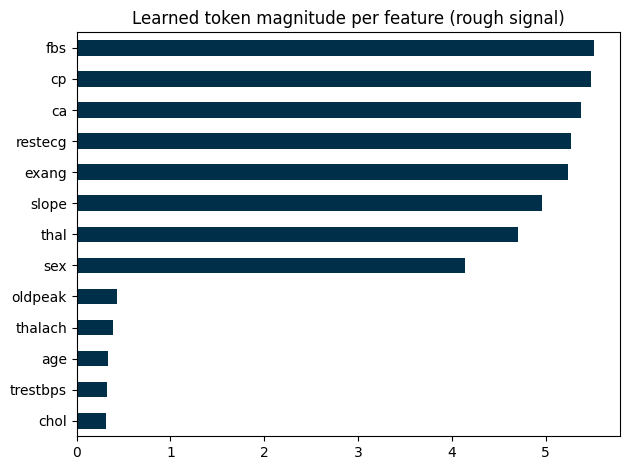

In [7]:
# Peek at what one patient's [CLS] token attended to is beyond a single hook, but we can read
# the learned per-feature embeddings' norms as a rough 'how much signal each feature token carries'.
with torch.no_grad():
    num_norm = model.tok.num_w.norm(dim=1).numpy()
    cat_norm = torch.stack([e.weight.norm(dim=1).mean() for e in model.tok.cat_emb]).numpy()
imp = pd.Series(np.concatenate([num_norm, cat_norm]), index=num_cols+cat_cols).sort_values()
imp.plot.barh(color="#003049"); import matplotlib.pyplot as plt
plt.title("Learned token magnitude per feature (rough signal)"); plt.tight_layout(); plt.show()

## Questions to think about
1. How did the transformer's AUC compare to gradient boosting on this 300-patient split? Was the extra machinery worth it here?
2. Try changing `d`, `heads`, or `layers` — does a bigger model help, or does it overfit (train loss down, test AUC flat)?
3. When would this architecture start to win: more patients, more high-cardinality categoricals, or joining images/notes?

*This is the practical companion to the attention lecture. For the concept from scratch, see `S6_DEMO.ipynb`.*